# Triage Classifier — Evaluation & Learning Curve (v2)

The classifier predicts five labels — **topic, type, priority, routing,
sentiment** — from a ticket's text, using the same 768-dim embeddings the RAG
uses for retrieval (one embedding infrastructure, two consumers).

The interesting question for a portfolio isn't just "what accuracy?" but **"how
does performance scale with data?"** We answer it with a **learning curve**: train
on growing subsets of the *same* v2 dataset and evaluate each on one **fixed**
held-out test set. This isolates the effect of *training size* — unlike comparing
the old 2k dataset to the new 24k one, which confounds *more data* with *a
different dataset*.

*Model: one-vs-rest logistic regression, `class_weight="balanced"`, per label.*

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# load the cached v2 embedding matrix + tickets directly (paths relative to
# notebooks/, so this runs correctly when the notebook's CWD is this folder)
X = np.load("../data/ticket_features_v2.npy")
tickets = [json.loads(l) for l in open("../data/tickets_v2.jsonl")]
assert X.shape[0] == len(tickets), "matrix / tickets length mismatch"
LABELS = ["topic", "type", "priority", "routing", "sentiment"]
print("feature matrix:", X.shape)

feature matrix: (23994, 768)


## Full-data performance (trained on 80%, tested on the held-out 20%)

In [2]:
idx = np.arange(len(X))
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=7)

def fit_eval(label, train_ids):
    y = np.array([t[label] for t in tickets])
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X[train_ids], y[train_ids])
    pred = clf.predict(X[te_idx])
    return (accuracy_score(y[te_idx], pred),
            f1_score(y[te_idx], pred, average="macro"))

full = {lab: fit_eval(lab, tr_idx) for lab in LABELS}
pd.DataFrame(full, index=["accuracy", "macro_F1"]).T.round(3)

,accuracy,macro_F1
topic,0.999,0.998
type,0.998,0.996
priority,0.995,0.992
routing,0.996,0.984
sentiment,0.863,0.806


## Learning curve — accuracy & macro-F1 vs training size

Same fixed test set throughout; training subsets are nested random draws of
increasing size from the 80% train pool.

In [3]:
rng = np.random.default_rng(7)
tr_shuf = rng.permutation(tr_idx)
sizes = [500, 1000, 2500, 5000, 10000, len(tr_idx)]

recs = []
for lab in LABELS:
    y = np.array([t[lab] for t in tickets])
    for n in sizes:
        sub = tr_shuf[:n]
        clf = LogisticRegression(max_iter=1000, class_weight="balanced")
        clf.fit(X[sub], y[sub])
        pred = clf.predict(X[te_idx])
        recs.append({"label": lab, "n_train": n,
                     "accuracy": accuracy_score(y[te_idx], pred),
                     "macro_F1": f1_score(y[te_idx], pred, average="macro")})
res = pd.DataFrame(recs)
print("done:", len(res), "fits")

done: 30 fits


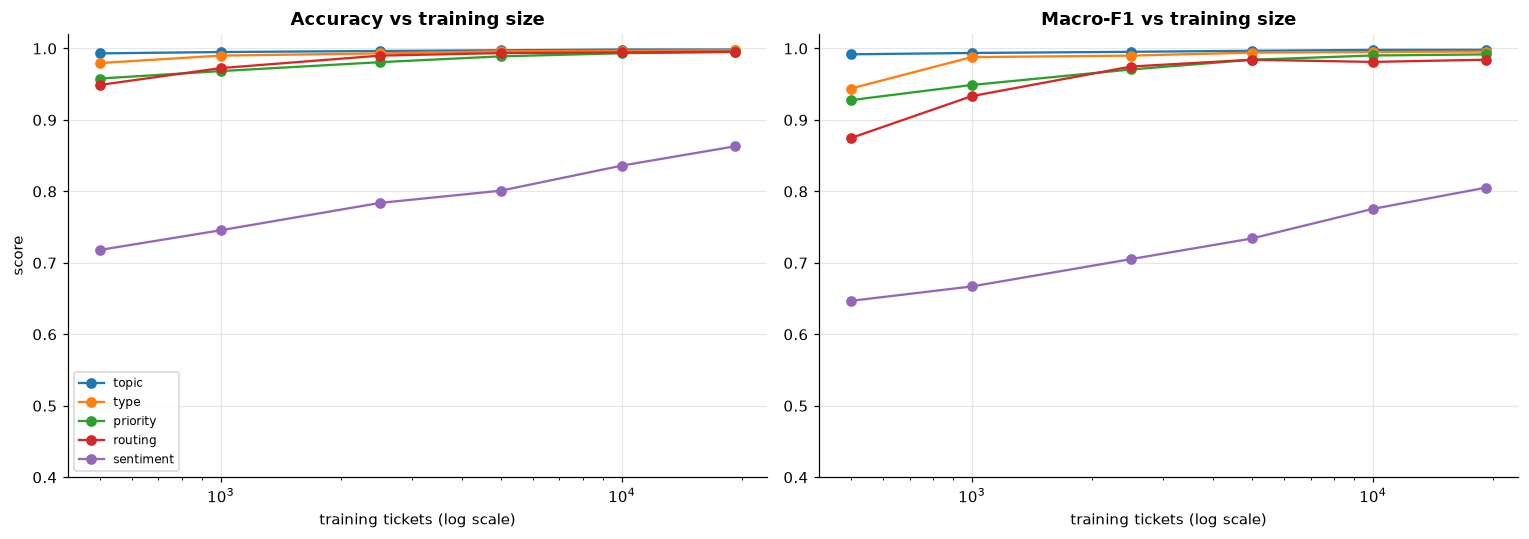

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lab in LABELS:
    d = res[res.label == lab]
    axes[0].plot(d.n_train, d.accuracy, marker="o", label=lab)
    axes[1].plot(d.n_train, d.macro_F1, marker="o", label=lab)
for ax, title in zip(axes, ["Accuracy vs training size", "Macro-F1 vs training size"]):
    ax.set_xscale("log"); ax.set_xlabel("training tickets (log scale)")
    ax.set_title(title, fontweight="bold"); ax.set_ylim(0.4, 1.02)
axes[0].set_ylabel("score"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Read it:** `topic`, `type`, `routing` and `priority` saturate early — they
are near-perfect with only ~1–2k tickets, so extra data barely moves them
(diminishing returns; the embedding already separates these classes cleanly).
`sentiment` is the one that keeps climbing with more data — it is the softest,
most ambiguous label, so it is the one that actually *needs* the 24k. That is the
honest payoff of scaling this dataset: it helps precisely where the model was
weakest.

### The learning curve as a table (macro-F1)

In [5]:
res.pivot(index="n_train", columns="label", values="macro_F1").round(3)

label,priority,routing,sentiment,topic,type
n_train,,,,,
500,0.928,0.875,0.647,0.992,0.944
1000,0.949,0.933,0.667,0.994,0.988
2500,0.971,0.975,0.705,0.995,0.990
5000,0.984,0.984,0.734,0.997,0.994
10000,0.990,0.981,0.775,0.998,0.995
19195,0.992,0.984,0.805,0.998,0.996


## Honest caveats (for the dataset card / interview)

- These scores are **high because the data is synthetic**: the text carries a
  clean signal to its label by construction. On real support tickets, expect
  lower — this is a demonstration of the *pipeline and method*, not a claim that
  the model is infallible.
- The concrete value is **fixing noisy intake**: the customer's own category is
  wrong ~35% of the time; the model recovers the true topic from the text (~65%
  picklist accuracy → near-perfect model). That routing lift is the business case.
- `sentiment` is treated as an **operational prioritization signal**, so the
  metric that matters there is recall on action-triggering emotions (angry /
  anxious), not raw accuracy.